In [5]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
# from tessrip import *
from tess_locator import locate, TessCoord
from astrocut import CutoutFactory

# Inspect TESS FFI cuts

In [13]:
sector = 8
camera = 4
ccd = 3

row = 1000
col = 810

cutout_size = 99

First we use `tess-locator` to convert pixel coordinates to RA and Dec

In [14]:
tcoord = TessCoord(sector=sector, camera=camera, ccd=ccd, column=col, row=row)
radec = tcoord.to_skycoord()
radec

<SkyCoord (ICRS): (ra, dec) in deg
    (69.01964444, -62.09759822)>

Get the cutout from the FFI cube using `AstroCut`

In [15]:
factory = CutoutFactory()
cube_file = (
    f"s3://stpubdata/tess/public/mast/tess-s{sector:04d}-{camera}-{ccd}-cube.fits"
)

In [16]:
output = (
            f"data/"
            f"TESScut_s{sector:04}-{camera}-{ccd}_c{col}_r{row}_{cutout_size}x{cutout_size}pix.fits"
        )

_ = factory.cube_cut(
                cube_file=cube_file,
                coordinates=radec,
                cutout_size=cutout_size,
                target_pixel_file=output,
                threads="auto",
            )

Open the cutout with `lightkurve`

In [19]:
tpf = lk.read(output, quality_bitmask=None)
tpf

TessTargetPixelFile(TICID: None)

<Axes: title={'center': 'Target ID: None, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

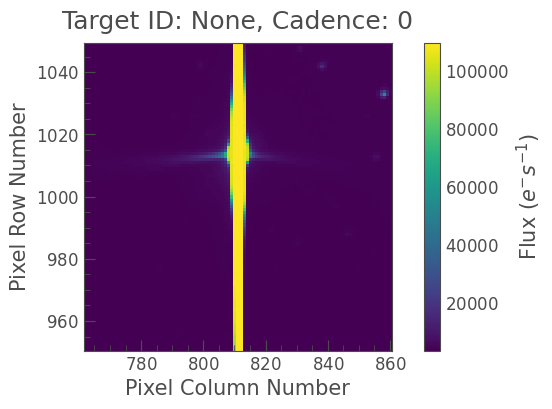

In [20]:
tpf.plot()